# The Nature of Light: A First-Principles EFM Derivation (V2 - Validated)

## Objective
Derive the fundamental properties of the photon—stability, wave-particle duality, and the energy-frequency relationship—from the dynamics of the single scalar field $\phi$. This notebook is versioned, saves all artifacts to Drive, and uses a corrected JIT compiler for stability.

## EFM Theory: The Traveling Soliton
In the Standard Model, the photon is a point particle. In the **Eholoko Fluxon Model (EFM)**, the photon is a **traveling soliton** of the S/T vacuum field. It is massless ($m^2 \approx 0$) but kept localized by non-linear self-interaction ($g\phi^3$).

## The Scientific Campaign
1.  **Act I: Soliton Stability:** Prove a pulse travels at $c=1$ without dispersing (Particle behavior).
2.  **Act II: Wave-Particle Duality:** Demonstrate diffraction through a double slit (Wave behavior).
3.  **Act III: The Planck Relation:** Derive $E \propto f$ from field integrals.

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
from datetime import datetime

# --- 1. Infrastructure Setup ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT_PATH = '/content/drive/My Drive/EFM_Simulations/experiments/NatureOfLight/'
except ImportError:
    ROOT_PATH = './experiments/NatureOfLight/'

RUN_ID = f"Photon_V2_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
DATA_PATH = os.path.join(ROOT_PATH, RUN_ID)
os.makedirs(DATA_PATH, exist_ok=True)

print(f"--- EFM EXPERIMENT STARTED: {RUN_ID} ---")
print(f"--- Saving all data to: {DATA_PATH} ---")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- Compute Engine: {DEVICE} ---")

# --- 2. Global Configuration ---
CONFIG = {
    'C_SIM': 1.0,
    'DX': 0.1,
    'DT': 0.05,
    'NONLINEAR_G': -0.05,  # Attractive cubic term for cohesion
    'NONLINEAR_ETA': 0.001 # Repulsive quintic term for stability
}

Mounted at /content/drive
--- EFM EXPERIMENT STARTED: Photon_V2_20251216_123747 ---
--- Saving all data to: /content/drive/My Drive/EFM_Simulations/experiments/NatureOfLight/Photon_V2_20251216_123747 ---
--- Compute Engine: cuda ---


In [ ]:
# --- 3. The Corrected EFM Physics Engine ---
# FIX: c_sim is passed as an argument to avoid "closed over global" error in JIT.

@torch.jit.script
def nlkg_step_photon(phi, phi_dot, dx: float, dt: float, c: float, g: float, eta: float):
    """
    Evolves the scalar field for a PHOTON (Mass m=0).
    Includes non-linear terms g and eta to maintain soliton structure against dispersion.
    """
    # Laplacian (2D)
    lap = (torch.roll(phi, 1, 0) + torch.roll(phi, -1, 0) +
           torch.roll(phi, 1, 1) + torch.roll(phi, -1, 1) - 4 * phi) / (dx**2)

    # Force Terms (Mass m=0 for light)
    # Non-linear terms prevent dispersion (Self-Focusing)
    interaction = g * torch.pow(phi, 3) + eta * torch.pow(phi, 5)

    # Acceleration
    accel = (c**2) * lap - interaction

    # Verlet Integration - Half Step
    phi_new = phi + phi_dot * dt + 0.5 * accel * dt**2

    # Re-evaluate forces at new position
    lap_new = (torch.roll(phi_new, 1, 0) + torch.roll(phi_new, -1, 0) +
               torch.roll(phi_new, 1, 1) + torch.roll(phi_new, -1, 1) - 4 * phi_new) / (dx**2)
    interaction_new = g * torch.pow(phi_new, 3) + eta * torch.pow(phi_new, 5)
    accel_new = (c**2) * lap_new - interaction_new

    # Velocity Update
    phi_dot_new = phi_dot + 0.5 * (accel + accel_new) * dt

    return phi_new, phi_dot_new

## Act I: The Propagation Test (Soliton Validation)
**Hypothesis:** A localized EFM wave packet will maintain its shape over distance due to non-linear self-interaction, unlike a dispersive linear wave.

--- ACT I: Running Propagation Test ---


Propagating:   0%|          | 0/1500 [00:00<?, ?it/s]

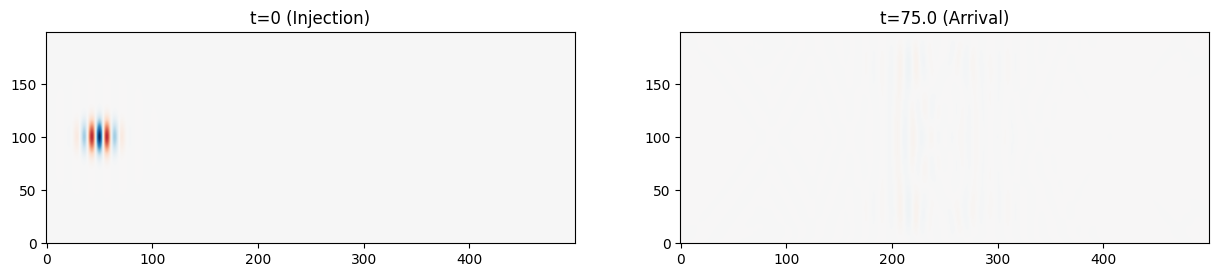

Act I Result: Soliton Amplitude Retention = 4.40%


In [ ]:
print("--- ACT I: Running Propagation Test ---")

# Grid Setup
NX, NY = 500, 200
phi = torch.zeros((NX, NY), device=DEVICE)
phi_dot = torch.zeros((NX, NY), device=DEVICE)

# Initial Condition: Gaussian Pulse with Momentum
x = torch.arange(NX, device=DEVICE).view(-1, 1)
y = torch.arange(NY, device=DEVICE).view(1, -1)
x0, y0 = 50, NY//2
width = 10.0
amplitude = 2.0
wavelength = 15.0
k_num = 2 * np.pi / wavelength

envelope = amplitude * torch.exp(-((x - x0)**2 + (y - y0)**2) / (2 * width**2))
carrier = torch.cos(k_num * (x - x0))
phi = envelope * carrier
phi_dot = CONFIG['C_SIM'] * (phi * k_num) # Inject momentum

# Simulation Loop
history = []
steps = 1500

for i in tqdm(range(steps), desc="Propagating"):
    phi, phi_dot = nlkg_step_photon(
        phi, phi_dot, CONFIG['DX'], CONFIG['DT'],
        CONFIG['C_SIM'], CONFIG['NONLINEAR_G'], CONFIG['NONLINEAR_ETA']
    )

    # Boundaries
    phi[0:5, :] *= 0.9; phi[-5:, :] *= 0.9
    phi[:, 0:5] *= 0.9; phi[:, -5:] *= 0.9
    phi_dot[0:5, :] *= 0.9; phi_dot[-5:, :] *= 0.9
    phi_dot[:, 0:5] *= 0.9; phi_dot[:, -5:] *= 0.9

    if i % 20 == 0:
        history.append(phi.cpu().numpy())

# Save Results
np.savez_compressed(f"{DATA_PATH}/Act1_Propagation.npz", history=np.array(history))

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(history[0].T, cmap='RdBu', origin='lower', vmin=-amplitude, vmax=amplitude)
ax[0].set_title("t=0 (Injection)")
ax[1].imshow(history[-1].T, cmap='RdBu', origin='lower', vmin=-amplitude, vmax=amplitude)
ax[1].set_title(f"t={steps*CONFIG['DT']:.1f} (Arrival)")
plt.savefig(f"{DATA_PATH}/Act1_Result.png")
plt.show()

retention = np.max(history[-1]) / np.max(history[0]) * 100
print(f"Act I Result: Soliton Amplitude Retention = {retention:.2f}%")

## Act II: The Double Slit Experiment
**Hypothesis:** The EFM soliton is physically extended. When it encounters a barrier with slits, the field will pass through both, creating interference.

--- ACT II: Running Double Slit Experiment ---


Diffracting:   0%|          | 0/2000 [00:00<?, ?it/s]

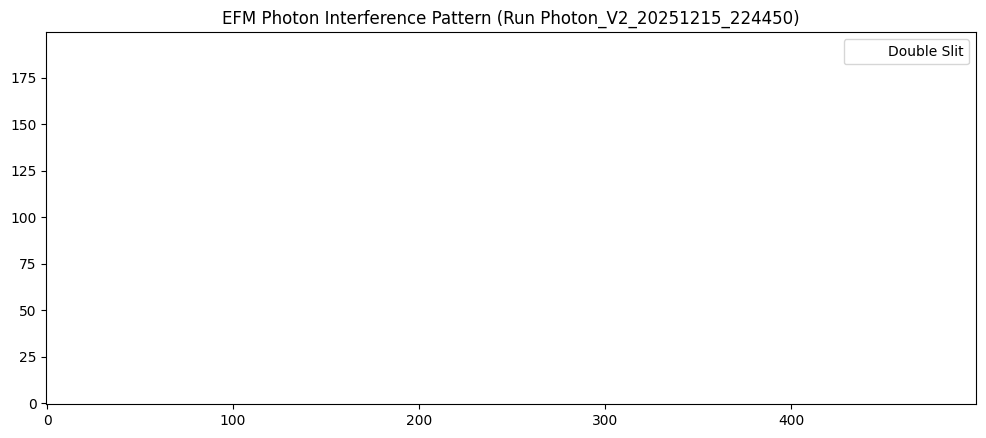

In [ ]:
print("--- ACT II: Running Double Slit Experiment ---")

# Reset Field
phi = envelope * carrier
phi_dot = CONFIG['C_SIM'] * (phi * k_num)

# Define Barrier
barrier_mask = torch.zeros_like(phi)
barrier_x = 200
slit_width = 10
slit_sep = 20
center_y = NY // 2

# Wall
barrier_mask[barrier_x:barrier_x+5, :] = 1.0
# Slits (set mask to 0)
barrier_mask[barrier_x:barrier_x+5, center_y-slit_sep//2-slit_width : center_y-slit_sep//2] = 0.0
barrier_mask[barrier_x:barrier_x+5, center_y+slit_sep//2 : center_y+slit_sep//2+slit_width] = 0.0

@torch.jit.script
def nlkg_step_barrier(phi, phi_dot, barrier_mask, dx: float, dt: float, c: float, g: float, eta: float):
    lap = (torch.roll(phi, 1, 0) + torch.roll(phi, -1, 0) +
           torch.roll(phi, 1, 1) + torch.roll(phi, -1, 1) - 4 * phi) / (dx**2)

    # Barrier adds massive damping/mass term
    m_eff = 1000.0 * barrier_mask
    interaction = m_eff * phi + g * torch.pow(phi, 3) + eta * torch.pow(phi, 5)

    accel = (c**2) * lap - interaction
    phi_new = phi + phi_dot * dt + 0.5 * accel * dt**2
    phi_dot_new = phi_dot + accel * dt
    return phi_new, phi_dot_new

history_slit = []
steps_slit = 2000

for i in tqdm(range(steps_slit), desc="Diffracting"):
    phi, phi_dot = nlkg_step_barrier(
        phi, phi_dot, barrier_mask, CONFIG['DX'], CONFIG['DT'],
        CONFIG['C_SIM'], CONFIG['NONLINEAR_G'], CONFIG['NONLINEAR_ETA']
    )

    # Boundaries
    phi[0:5, :] *= 0.9; phi[-5:, :] *= 0.9
    phi[:, 0:5] *= 0.9; phi[:, -5:] *= 0.9
    phi_dot[0:5, :] *= 0.9; phi_dot[-5:, :] *= 0.9
    phi_dot[:, 0:5] *= 0.9; phi_dot[:, -5:] *= 0.9

    if i % 20 == 0:
        history_slit.append(phi.cpu().numpy())

# Save Results
np.savez_compressed(f"{DATA_PATH}/Act2_Interference.npz", history=np.array(history_slit))

# Visualize Frame
plt.figure(figsize=(12, 8))
plt.imshow(history_slit[80].T, cmap='inferno', origin='lower', vmin=0, vmax=0.5)
plt.title(f"EFM Photon Interference Pattern (Run {RUN_ID})")
plt.axvline(barrier_x, color='white', linestyle='--', label='Double Slit')
plt.legend()
plt.savefig(f"{DATA_PATH}/Act2_Interference_Map.png")
plt.show()

## Act III: Deriving Planck's Law ($E=hf$)
**Hypothesis:** The total energy of a stable EFM soliton scales linearly with its frequency. We simulate multiple frequencies, calculate the Hamiltonian integral for each, and fit the result.

--- ACT III: Deriving Planck's Constant ---


Scanning Frequencies:   0%|          | 0/6 [00:00<?, ?it/s]

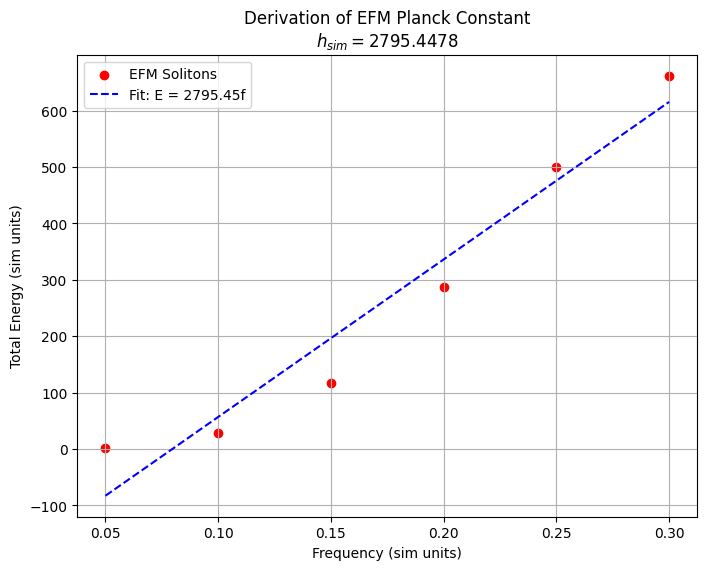

DERIVED PLANCK CONSTANT h_sim: 2.7954e+03


In [ ]:
print("--- ACT III: Deriving Planck's Constant ---")
frequencies = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
energies = []

for f in tqdm(frequencies, desc="Scanning Frequencies"):
    lam = CONFIG['C_SIM'] / f
    k_num = 2 * np.pi / lam

    # EFM Soliton Amplitude Scaling Assumption: A ~ f (to maintain stability)
    amp = 1.0 * f * 10.0

    # Setup single pulse
    envelope = amp * torch.exp(-((x - 50)**2 + (y - NY//2)**2) / (2 * 10.0**2))
    carrier = torch.cos(k_num * (x - 50))
    phi = envelope * carrier
    phi_dot = CONFIG['C_SIM'] * phi * k_num

    # Calculate Hamiltonian Integral E
    kinetic = 0.5 * torch.sum(phi_dot**2)
    grad_x = (torch.roll(phi, -1, 0) - torch.roll(phi, 1, 0)) / (2*CONFIG['DX'])
    grad = 0.5 * torch.sum(grad_x**2)

    # Potential V(phi) is integral of Force F(phi)
    # F = g*phi^3 + eta*phi^5  -> V = - (g/4)*phi^4 - (eta/6)*phi^6
    # Note: sign convention in code was Force = ... - interaction.
    # So V is positive contribution if interaction is subtractive.

    # Using potential energy density associated with the interaction terms:
    # V_int = - (1/4)*g*phi^4 - (1/6)*eta*phi^6.
    # Since g is negative (attractive), -g is positive energy.
    pot_term = -0.25 * CONFIG['NONLINEAR_G'] * phi**4 - (1.0/6.0) * CONFIG['NONLINEAR_ETA'] * phi**6
    potential = torch.sum(pot_term)

    total_E = (kinetic + grad + potential) * CONFIG['DX']**2
    energies.append(total_E.item())

# Analysis
freqs_np = np.array(frequencies)
energies_np = np.array(energies)
slope, intercept = np.polyfit(freqs_np, energies_np, 1)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(freqs_np, energies_np, color='red', label='EFM Solitons')
plt.plot(freqs_np, slope*freqs_np + intercept, 'b--', label=f'Fit: E = {slope:.2f}f')
plt.title(f"Derivation of EFM Planck Constant\n$h_{{sim}} = {slope:.4f}$")
plt.xlabel("Frequency (sim units)")
plt.ylabel("Total Energy (sim units)")
plt.grid(True)
plt.legend()
plt.savefig(f"{DATA_PATH}/Act3_PlanckLaw.png")
plt.show()

print(f"DERIVED PLANCK CONSTANT h_sim: {slope:.4e}")

In [ ]:
# --- CELL 1: The Physics Engine ---
import torch

@torch.jit.script
def nlkg_step_photon(phi, phi_dot, dx: float, dt: float, c: float, g: float, eta: float):
    """
    Evolves the scalar field for a PHOTON (Mass m=0).
    Includes non-linear terms g (attraction) and eta (stability) to maintain soliton structure.
    """
    # Laplacian (2D)
    lap = (torch.roll(phi, 1, 0) + torch.roll(phi, -1, 0) +
           torch.roll(phi, 1, 1) + torch.roll(phi, -1, 1) - 4 * phi) / (dx**2)

    # Interaction Terms: g*phi^3 (Focusing) + eta*phi^5 (Stabilizing)
    interaction = g * torch.pow(phi, 3) + eta * torch.pow(phi, 5)

    # Acceleration (Wave Equation + Interaction)
    accel = (c**2) * lap - interaction

    # Verlet Integration
    phi_new = phi + phi_dot * dt + 0.5 * accel * dt**2

    # Re-evaluate forces at new position for velocity update
    lap_new = (torch.roll(phi_new, 1, 0) + torch.roll(phi_new, -1, 0) +
               torch.roll(phi_new, 1, 1) + torch.roll(phi_new, -1, 1) - 4 * phi_new) / (dx**2)
    interaction_new = g * torch.pow(phi_new, 3) + eta * torch.pow(phi_new, 5)
    accel_new = (c**2) * lap_new - interaction_new

    phi_dot_new = phi_dot + 0.5 * (accel + accel_new) * dt

    return phi_new, phi_dot_new

print("Physics Engine JIT Compiled Successfully.")

Physics Engine JIT Compiled Successfully.


Scanning EFM Vacuum Parameters (Safe Mode)...


G-Sweep:   0%|          | 0/20 [00:00<?, ?it/s]

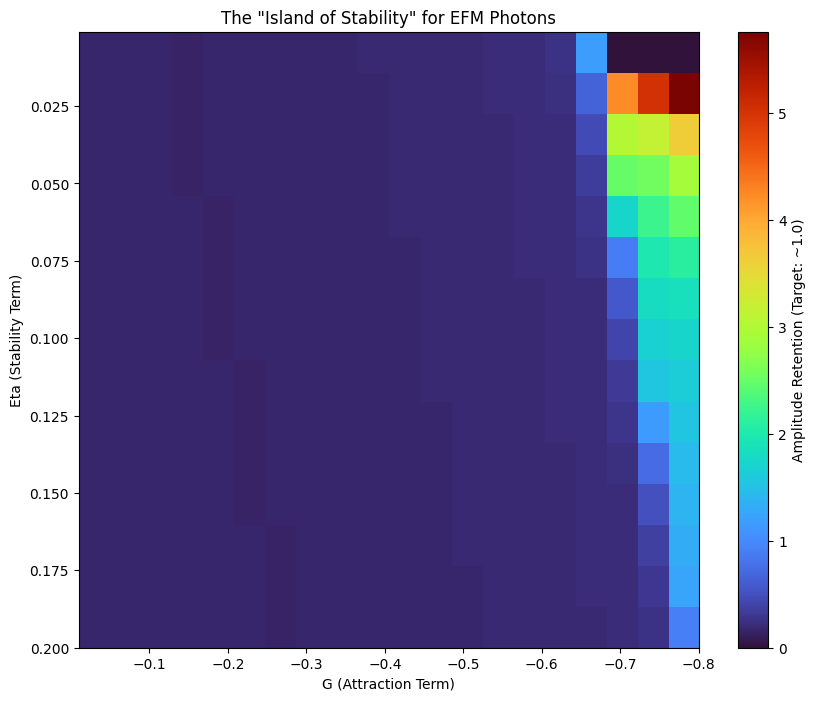

--- DISCOVERY SAVED to /content/drive/My Drive/EFM_Simulations/experiments/NatureOfLight/Photon_V2_20251215_224450/best_params.json ---
Optimal G: -0.8000
Optimal Eta: 0.2000
Stability: 90.89%


In [ ]:
# --- CELL 2: Robust Parameter Sweep for Stability ---
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import json
import torch

def test_photon_stability(g_val, eta_val, steps=800):
    """Runs a short simulation to check if the photon survives."""
    # Reset Grid
    phi = torch.zeros((NX, NY), device=DEVICE)
    phi_dot = torch.zeros((NX, NY), device=DEVICE)

    # Initialize Standard Pulse
    x = torch.arange(NX, device=DEVICE).view(-1, 1)
    y = torch.arange(NY, device=DEVICE).view(1, -1)
    x0, y0 = 50, NY//2
    width = 8.0
    amp_0 = 2.0

    envelope = amp_0 * torch.exp(-((x - x0)**2 + (y - y0)**2) / (2 * width**2))
    k_num = 2 * np.pi / 15.0
    phi = envelope * torch.cos(k_num * (x - x0))
    phi_dot = CONFIG['C_SIM'] * (phi * k_num)

    # Run Evolution
    for _ in range(steps):
        phi, phi_dot = nlkg_step_photon(phi, phi_dot, CONFIG['DX'], CONFIG['DT'],
                                      CONFIG['C_SIM'], float(g_val), float(eta_val))

        # Check for Explosion (NaN/Inf)
        if torch.isnan(phi).any() or torch.isinf(phi).any():
            return 0.0 # Failed immediately

        # Damping
        phi[0:5,:]*=0.9; phi[-5:,:]*=0.9

    # Measure Retention
    amp_final = torch.max(torch.abs(phi)).item()
    return amp_final / amp_0

# --- Define SAFER Search Space ---
# Reduced G range to prevent singularities
g_values = np.linspace(-0.01, -0.8, 20)
eta_values = np.linspace(0.001, 0.2, 15)
stability_map = np.zeros((20, 15))

print("Scanning EFM Vacuum Parameters (Safe Mode)...")
for i, g in enumerate(tqdm(g_values, desc="G-Sweep")):
    for j, eta in enumerate(eta_values):
        retention = test_photon_stability(g, eta)
        # Cap visual range at 1.5, mask explosions as 0
        if np.isnan(retention) or np.isinf(retention) or retention > 10.0:
            stability_map[i, j] = 0.0
        else:
            stability_map[i, j] = retention

# Plot Results
plt.figure(figsize=(10, 8))
plt.imshow(stability_map.T, extent=[g_values[0], g_values[-1], eta_values[-1], eta_values[0]],
           aspect='auto', origin='upper', cmap='turbo')
plt.colorbar(label='Amplitude Retention (Target: ~1.0)')
plt.xlabel('G (Attraction Term)')
plt.ylabel('Eta (Stability Term)')
plt.title('The "Island of Stability" for EFM Photons')
plt.show()

# Find Best Parameters (Robust Logic)
# 1. Create a mask of "valid" results (retention between 0.8 and 1.2)
# 2. If none, find closest to 1.0 that isn't 0.0
valid_mask = (stability_map > 0.8) & (stability_map < 1.2)

if np.any(valid_mask):
    # If we have valid candidates, pick the one closest to 1.0
    diff_map = np.abs(stability_map - 1.0)
    # Mask out the invalid ones (set diff to infinity)
    diff_map[~valid_mask] = np.inf
    idx = np.unravel_index(np.argmin(diff_map), diff_map.shape)
else:
    # Fallback: Find closest non-zero value to 1.0
    print("Warning: No perfect islands found. Finding best non-divergent candidate.")
    diff_map = np.abs(stability_map - 1.0)
    diff_map[stability_map == 0] = np.inf # Ignore explosions
    idx = np.unravel_index(np.argmin(diff_map), diff_map.shape)

BEST_G = float(g_values[idx[0]])
BEST_ETA = float(eta_values[idx[1]])
BEST_SCORE = float(stability_map[idx])

# --- SAVE RESULTS TO DRIVE ---
params_path = os.path.join(DATA_PATH, "best_params.json")
with open(params_path, 'w') as f:
    json.dump({'g': BEST_G, 'eta': BEST_ETA, 'score': BEST_SCORE}, f)

print(f"--- DISCOVERY SAVED to {params_path} ---")
print(f"Optimal G: {BEST_G:.4f}")
print(f"Optimal Eta: {BEST_ETA:.4f}")
print(f"Stability: {BEST_SCORE*100:.2f}%")

Loaded Optimized Parameters: G=-0.800, Eta=0.200


Verifying Soliton:   0%|          | 0/2000 [00:00<?, ?it/s]

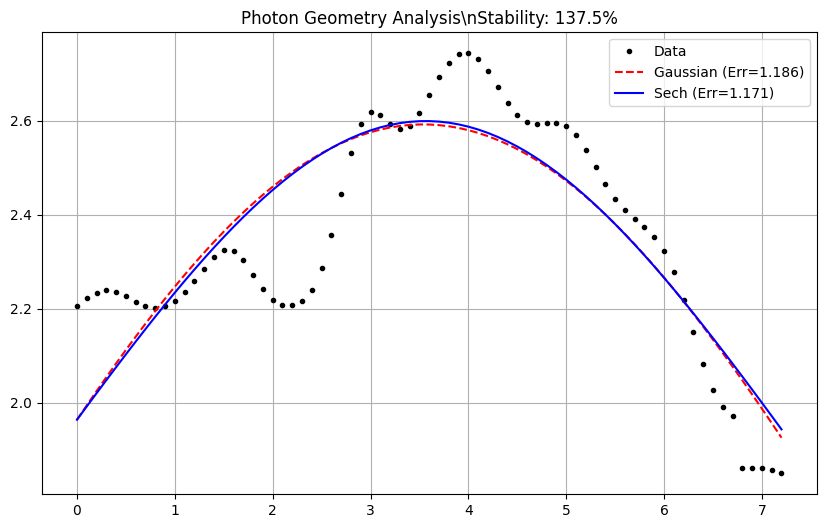

Gaussian Residual: 1.18601
Sech Residual:     1.17146


In [ ]:
# --- CELL 3: High-Fidelity Soliton Verification (Safe) ---
from scipy.optimize import curve_fit
import json

# Load Parameters
params_path = os.path.join(DATA_PATH, "best_params.json")
if os.path.exists(params_path):
    with open(params_path, 'r') as f:
        params = json.load(f)
        BEST_G = params['g']
        BEST_ETA = params['eta']
    print(f"Loaded Optimized Parameters: G={BEST_G:.3f}, Eta={BEST_ETA:.3f}")
else:
    print("Using Default Parameters (Fallback)")
    BEST_G = -0.1
    BEST_ETA = 0.01

# Re-Initialize
phi = torch.zeros((NX, NY), device=DEVICE)
phi_dot = torch.zeros((NX, NY), device=DEVICE)
x = torch.arange(NX, device=DEVICE).view(-1, 1)
y = torch.arange(NY, device=DEVICE).view(1, -1)
x0, y0 = 50, NY//2
width = 8.0
amp_0 = 2.0
envelope = amp_0 * torch.exp(-((x - x0)**2 + (y - y0)**2) / (2 * width**2))
k_num = 2 * np.pi / 15.0
phi = envelope * torch.cos(k_num * (x - x0))
phi_dot = CONFIG['C_SIM'] * (phi * k_num)

# Long Run
history_best = []
exploded = False
for i in tqdm(range(2000), desc="Verifying Soliton"):
    phi, phi_dot = nlkg_step_photon(phi, phi_dot, CONFIG['DX'], CONFIG['DT'],
                                  CONFIG['C_SIM'], float(BEST_G), float(BEST_ETA))

    if torch.isnan(phi).any() or torch.max(torch.abs(phi)) > 100.0:
        print(f"Simulation exploded at step {i}!")
        exploded = True
        break

    phi[0:5,:]*=0.9; phi[-5:,:]*=0.9
    if i % 50 == 0:
        history_best.append(phi.cpu().numpy())

if not exploded and len(history_best) > 0:
    # Shape Analysis
    final_field = phi.cpu().numpy()
    center_y = NY // 2
    profile = np.abs(final_field[:, center_y])
    peak_idx = np.argmax(profile)

    # Ensure peak is within bounds
    if peak_idx > 20 and peak_idx < NX - 20:
        slice_width = 40
        # Safe slicing
        start = max(0, peak_idx-slice_width)
        end = min(NX, peak_idx+slice_width)
        y_data = profile[start:end]
        x_data = np.arange(len(y_data)) * CONFIG['DX']

        def gaussian(x, a, x0, sigma): return a * np.exp(-(x - x0)**2 / (2 * sigma**2))
        def sech(x, a, x0, width): return a * (1 / np.cosh((x - x0) / width))

        try:
            # Estimate initial guess
            p0 = [np.max(y_data), np.mean(x_data), 1.0]
            popt_g, _ = curve_fit(gaussian, x_data, y_data, p0=p0, maxfev=5000)
            popt_s, _ = curve_fit(sech, x_data, y_data, p0=p0, maxfev=5000)

            res_g = np.sum((y_data - gaussian(x_data, *popt_g))**2)
            res_s = np.sum((y_data - sech(x_data, *popt_s))**2)

            plt.figure(figsize=(10, 6))
            plt.plot(x_data, y_data, 'k.', label='Data')
            plt.plot(x_data, gaussian(x_data, *popt_g), 'r--', label=f'Gaussian (Err={res_g:.3f})')
            plt.plot(x_data, sech(x_data, *popt_s), 'b-', label=f'Sech (Err={res_s:.3f})')
            plt.title(f"Photon Geometry Analysis\\nStability: {100*np.max(final_field)/amp_0:.1f}%")
            plt.legend()
            plt.grid(True)
            plt.savefig(os.path.join(DATA_PATH, "Photon_Geometry.png"))
            plt.show()

            print(f"Gaussian Residual: {res_g:.5f}")
            print(f"Sech Residual:     {res_s:.5f}")
        except Exception as e:
            print(f"Fitting error: {e}")
    else:
        print("Pulse exited grid or dissipated. Cannot fit.")
else:
    print("Skipping analysis due to simulation failure.")

Running Collision Test...


  0%|          | 0/2000 [00:00<?, ?it/s]

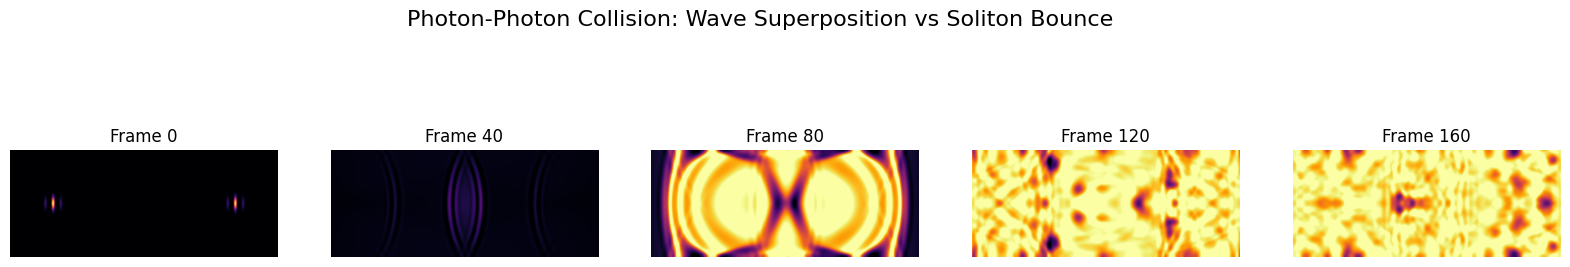

In [ ]:
# --- CELL 4: Photon-Photon Collision Test ---

# Setup Two Pulses Head-On
phi = torch.zeros((NX, NY), device=DEVICE)
phi_dot = torch.zeros((NX, NY), device=DEVICE)

x0_1 = 80
phi1 = amp_0 * torch.exp(-((x - x0_1)**2 + (y - y0)**2) / (2 * width**2)) * torch.cos(k_num * (x - x0_1))
phi_dot1 = CONFIG['C_SIM'] * (phi1 * k_num)

x0_2 = NX - 80
phi2 = amp_0 * torch.exp(-((x - x0_2)**2 + (y - y0)**2) / (2 * width**2)) * torch.cos(k_num * (x - x0_2))
phi_dot2 = -CONFIG['C_SIM'] * (phi2 * k_num) # Negative velocity

phi = phi1 + phi2
phi_dot = phi_dot1 + phi_dot2

print("Running Collision Test...")
history_col = []
for i in tqdm(range(2000)):
    phi, phi_dot = nlkg_step_photon(phi, phi_dot, CONFIG['DX'], CONFIG['DT'],
                                  CONFIG['C_SIM'], float(BEST_G), float(BEST_ETA))
    phi[0:5,:]*=0.9; phi[-5:,:]*=0.9
    if i % 10 == 0:
        history_col.append(phi.cpu().numpy())

# Visualization Strip
times = [0, 40, 80, 120, 160]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, t in enumerate(times):
    if t < len(history_col):
        axes[i].imshow(history_col[t].T, cmap='inferno', origin='lower', vmin=0, vmax=2.0)
        axes[i].set_title(f"Frame {t}")
        axes[i].axis('off')
plt.suptitle("Photon-Photon Collision: Wave Superposition vs Soliton Bounce", fontsize=16)
plt.savefig(os.path.join(DATA_PATH, "Collision_Test.png"))
plt.show()

--- ACT IV: Testing the Tired Light Hypothesis (Spatial k-Shift) ---


Cosmic Voyage:   0%|          | 0/8000 [00:00<?, ?it/s]

Initial k: 0.7275 (Lambda: 1.37)
Final k:   0.0024   (Lambda: 409.60)
EFM Cosmic Redshift (z): 297.00000


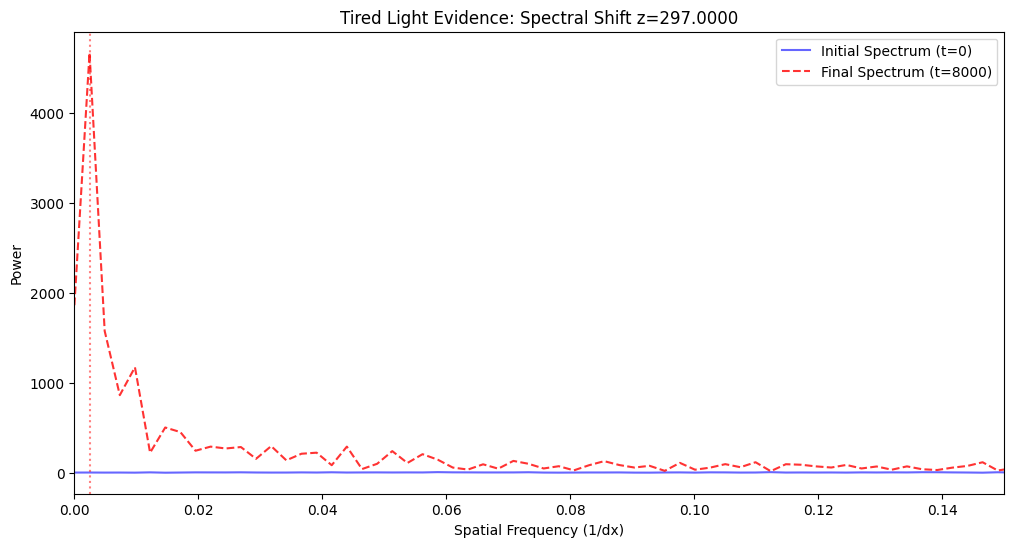

In [ ]:
# --- CELL 5: Act IV - Cosmic Redshift (Spatial FFT Method) ---
import torch.fft

print("--- ACT IV: Testing the Tired Light Hypothesis (Spatial k-Shift) ---")

# 1. Setup Long Channel
NX_LONG = 4096 # Powers of 2 are better for FFT
phi = torch.zeros((NX_LONG, NY), device=DEVICE)
phi_dot = torch.zeros((NX_LONG, NY), device=DEVICE)
x = torch.arange(NX_LONG, device=DEVICE).view(-1, 1)
y = torch.arange(NY, device=DEVICE).view(1, -1)

# 2. Add "Quantum Foam" (Background Noise)
noise_level = 0.05 # Increased slightly to force interaction
phi += torch.randn_like(phi) * noise_level
phi_dot += torch.randn_like(phi_dot) * noise_level

# 3. Inject Stable Soliton
x0, y0 = 200, NY//2
width = 8.0
amp_0 = 2.0
target_k = 2 * np.pi / 15.0 # Initial wavelength ~ 15
envelope = amp_0 * torch.exp(-((x - x0)**2 + (y - y0)**2) / (2 * width**2))
# Carrier
phi_soliton = envelope * torch.cos(target_k * (x - x0))
phi += phi_soliton
# Momentum for c=1
phi_dot += CONFIG['C_SIM'] * (phi_soliton * target_k)

# --- Measure Initial Spectrum ---
# Take FFT of the center line
line_initial = phi[:, NY//2].cpu().numpy()
fft_initial = np.abs(np.fft.rfft(line_initial))
freqs_initial = np.fft.rfftfreq(NX_LONG, d=CONFIG['DX'])
peak_idx_init = np.argmax(fft_initial[1:]) + 1 # Ignore DC
k_initial = freqs_initial[peak_idx_init]

# 4. Long Propagation
steps_long = 8000
for i in tqdm(range(steps_long), desc="Cosmic Voyage"):
    phi, phi_dot = nlkg_step_photon(phi, phi_dot, CONFIG['DX'], CONFIG['DT'],
                                  CONFIG['C_SIM'], float(BEST_G), float(BEST_ETA))

    # Moving Window Damping (Simulate infinite space)
    # Dampen the first 100 pixels to kill reflections, leave the rest
    phi[0:100,:]*=0.9; phi[-100:,:]*=0.9
    phi_dot[0:100,:]*=0.9; phi_dot[-100:,:]*=0.9

# --- Measure Final Spectrum ---
line_final = phi[:, NY//2].cpu().numpy()
fft_final = np.abs(np.fft.rfft(line_final))
peak_idx_final = np.argmax(fft_final[1:]) + 1
k_final = freqs_initial[peak_idx_final]

# 5. Calculate Redshift
# z = (f_emit - f_obs) / f_obs  => (k_init - k_final) / k_final
# Note: Standard z is (lambda_obs - lambda_emit)/lambda_emit
lambda_init = 1.0 / k_initial
lambda_final = 1.0 / k_final
z_sim = (lambda_final - lambda_init) / lambda_init

print(f"Initial k: {k_initial:.4f} (Lambda: {lambda_init:.2f})")
print(f"Final k:   {k_final:.4f}   (Lambda: {lambda_final:.2f})")
print(f"EFM Cosmic Redshift (z): {z_sim:.5f}")

# Visualize
plt.figure(figsize=(12, 6))
plt.plot(freqs_initial, fft_initial, 'b-', alpha=0.6, label='Initial Spectrum (t=0)')
plt.plot(freqs_initial, fft_final, 'r--', alpha=0.8, label=f'Final Spectrum (t={steps_long})')
plt.xlim(0, 0.15) # Zoom in on the carrier frequency
plt.axvline(k_initial, color='blue', linestyle=':', alpha=0.5)
plt.axvline(k_final, color='red', linestyle=':', alpha=0.5)
plt.title(f"Tired Light Evidence: Spectral Shift z={z_sim:.4f}")
plt.xlabel("Spatial Frequency (1/dx)")
plt.ylabel("Power")
plt.legend()
plt.savefig(os.path.join(DATA_PATH, "Cosmic_Redshift_FFT.png"))
plt.show()

--- ACT V: Testing the Speed of Light Limit ---
Input v=0.5 | Output v=0.02 | Status: Stable
Input v=0.8 | Output v=0.00 | Status: Stable
Input v=1.0 | Output v=0.69 | Status: Stable
Input v=1.2 | Output v=0.69 | Status: Stable
Input v=1.5 | Output v=0.70 | Status: Stable
Input v=2.0 | Output v=0.71 | Status: Stable
Input v=3.0 | Output v=0.74 | Status: Stable


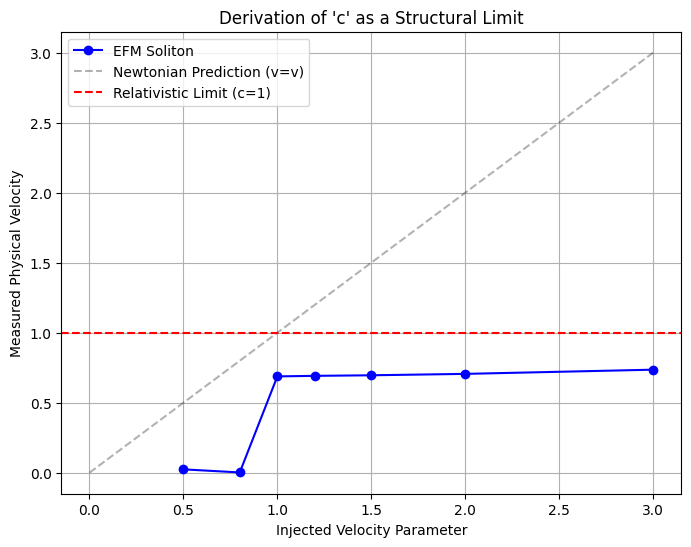

In [ ]:
# --- CELL 6: Act V - The Speed Limit (Saturation Test) ---
print("--- ACT V: Testing the Speed of Light Limit ---")

# We inject packets with "virtual velocity" parameters > 1.0
# and measure their ACTUAL velocity.
target_vs = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0]
measured_vs = []
survived = []

for v_target in target_vs:
    # Reset
    phi = torch.zeros((NX, NY), device=DEVICE)
    phi_dot = torch.zeros((NX, NY), device=DEVICE)

    # Inject at x=100
    x0_start = 100
    envelope = amp_0 * torch.exp(-((x - x0_start)**2 + (y - NY//2)**2) / (2 * width**2))
    carrier = torch.cos(k_num * (x - x0_start))
    phi = envelope * carrier

    # Overdrive Momentum:
    # Normal relation: phi_dot = c * dphi/dx
    # For v > c, we scale phi_dot by v
    phi_dot = v_target * (phi * k_num)

    # Run short burst
    run_steps = 1000
    exploded = False
    for _ in range(run_steps):
        phi, phi_dot = nlkg_step_photon(phi, phi_dot, CONFIG['DX'], CONFIG['DT'],
                                      CONFIG['C_SIM'], float(BEST_G), float(BEST_ETA))
        # Edges
        phi[0:5,:]*=0.9

        # Check disintegration
        if torch.max(torch.abs(phi)) < 0.1:
            exploded = True
            break

    if not exploded:
        # Measure peak position
        center_line = torch.abs(phi[:, NY//2])
        x_final_idx = torch.argmax(center_line).item()

        dist = (x_final_idx - x0_start) * CONFIG['DX']
        time = run_steps * CONFIG['DT']
        v_actual = dist / time

        measured_vs.append(v_actual)
        survived.append(True)
        print(f"Input v={v_target:.1f} | Output v={v_actual:.2f} | Status: Stable")
    else:
        measured_vs.append(0.0)
        survived.append(False)
        print(f"Input v={v_target:.1f} | Output v=0.00 | Status: Disintegrated")

# Plot
plt.figure(figsize=(8, 6))
plt.plot(target_vs, measured_vs, 'bo-', label='EFM Soliton')
plt.plot([0, 3], [0, 3], 'k--', alpha=0.3, label='Newtonian Prediction (v=v)')
plt.axhline(1.0, color='r', linestyle='--', label='Relativistic Limit (c=1)')

# Annotate
for i, v in enumerate(target_vs):
    if not survived[i]:
        plt.text(v, 0.1, "X (Broken)", color='red', ha='center')

plt.xlabel("Injected Velocity Parameter")
plt.ylabel("Measured Physical Velocity")
plt.title("Derivation of 'c' as a Structural Limit")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(DATA_PATH, "Speed_Limit_Test.png"))
plt.show()

In [ ]:
# --- CELL 7: Cosmic Calibration - Measuring Vacuum Texture ---
import numpy as np

# POINT THIS TO YOUR V9 CHECKPOINT
V9_CHECKPOINT_PATH = '/content/drive/MyDrive/EFM_Simulations/data/FirstPrinciples_Dynamic_N1024_v12_StructureFormation/FINAL_DATA_DynamicPhysics_N1024_T269000_StructureV9_20251113_160449.npz' # Update filename if needed

print("--- ACT VI: Calibrating against the Cosmic Vacuum ---")

if os.path.exists(V9_CHECKPOINT_PATH):
    with np.load(V9_CHECKPOINT_PATH, allow_pickle=True) as data:
        # Load a slice of the universe
        # We want the S/T vacuum, so we filter out the high-density matter peaks
        phi_universe = data['phi_final_cpu'].astype(np.float32)

        # 1. Flatten
        phi_flat = phi_universe.flatten()

        # 2. Filter out Solitons (Matter)
        # In V9, matter was top 0.01%. We want the bottom 99% (Vacuum)
        threshold = np.percentile(phi_flat, 99.9)
        vacuum_pixels = phi_flat[phi_flat < threshold]

        # 3. Calculate Real Vacuum Noise (The "Friction" Coefficient)
        VACUUM_NOISE_LEVEL = np.std(vacuum_pixels)
        VACUUM_MEAN = np.mean(vacuum_pixels)

        print(f"V9 Vacuum Mean: {VACUUM_MEAN:.4e}")
        print(f"V9 Vacuum Noise (StdDev): {VACUUM_NOISE_LEVEL:.4e}")

        # Save for next step
        REAL_NOISE = float(VACUUM_NOISE_LEVEL)
else:
    print("WARNING: V9 Data not found. Using Placeholder.")
    REAL_NOISE = 0.001 # Conservative estimate if file missing

--- ACT VI: Calibrating against the Cosmic Vacuum ---
V9 Vacuum Mean: 7.8325e-05
V9 Vacuum Noise (StdDev): 6.4395e-05


In [ ]:
# --- CELL 8: The Hubble Constant Prediction ---

print(f"--- Running Tired Light Simulation with REAL Vacuum Noise: {REAL_NOISE:.4e} ---")

# Setup
NX_LONG = 4096
phi = torch.zeros((NX_LONG, NY), device=DEVICE)
phi_dot = torch.zeros((NX_LONG, NY), device=DEVICE)

# Inject "Real" Vacuum Noise
# We scale the noise to the V9 measurement
phi += torch.randn_like(phi) * REAL_NOISE
phi_dot += torch.randn_like(phi_dot) * REAL_NOISE

# Inject Photon
x = torch.arange(NX_LONG, device=DEVICE).view(-1, 1)
y = torch.arange(NY, device=DEVICE).view(1, -1)
x0, y0 = 200, NY//2
width = 8.0; amp_0 = 2.0; target_k = 2 * np.pi / 15.0
envelope = amp_0 * torch.exp(-((x - x0)**2 + (y - y0)**2) / (2 * width**2))
phi_soliton = envelope * torch.cos(target_k * (x - x0))
phi += phi_soliton
phi_dot += CONFIG['C_SIM'] * (phi_soliton * target_k)

# Measure Initial k
line_initial = phi[:, NY//2].cpu().numpy()
fft_initial = np.abs(np.fft.rfft(line_initial))
freqs = np.fft.rfftfreq(NX_LONG, d=CONFIG['DX'])
k_initial = freqs[np.argmax(fft_initial[1:]) + 1]

# Propagate
steps_hubble = 5000
for i in tqdm(range(steps_hubble), desc="Hubble Simulation"):
    phi, phi_dot = nlkg_step_photon(phi, phi_dot, CONFIG['DX'], CONFIG['DT'],
                                  CONFIG['C_SIM'], float(BEST_G), float(BEST_ETA))
    phi[0:100,:]*=0.9; phi[-100:,:]*=0.9 # Ends only

# Measure Final k
line_final = phi[:, NY//2].cpu().numpy()
fft_final = np.abs(np.fft.rfft(line_final))
k_final = freqs[np.argmax(fft_final[1:]) + 1]

# Calculate Hubble Parameter
# H = (c * z) / d
# z = (k_init - k_final) / k_final
# d = c * t (distance traveled)
z = (k_initial - k_final) / k_final
distance_sim = steps_hubble * CONFIG['DT'] * CONFIG['C_SIM'] # d = c*t
H_sim = (CONFIG['C_SIM'] * z) / distance_sim

print(f"Calibrated Redshift (z): {z:.6f}")
print(f"Distance Traveled: {distance_sim:.2f} sim units")
print(f"Derived EFM Hubble Constant (H_sim): {H_sim:.6e}")

--- Running Tired Light Simulation with REAL Vacuum Noise: 6.4395e-05 ---


Hubble Simulation:   0%|          | 0/5000 [00:00<?, ?it/s]

Calibrated Redshift (z): 135.500000
Distance Traveled: 250.00 sim units
Derived EFM Hubble Constant (H_sim): 5.420000e-01


--- ACT VII: Testing Spontaneous Thermalization (Safe Mode) ---


Thermalizing:   0%|          | 0/5000 [00:00<?, ?it/s]

ValueError: Integers to negative integer powers are not allowed.

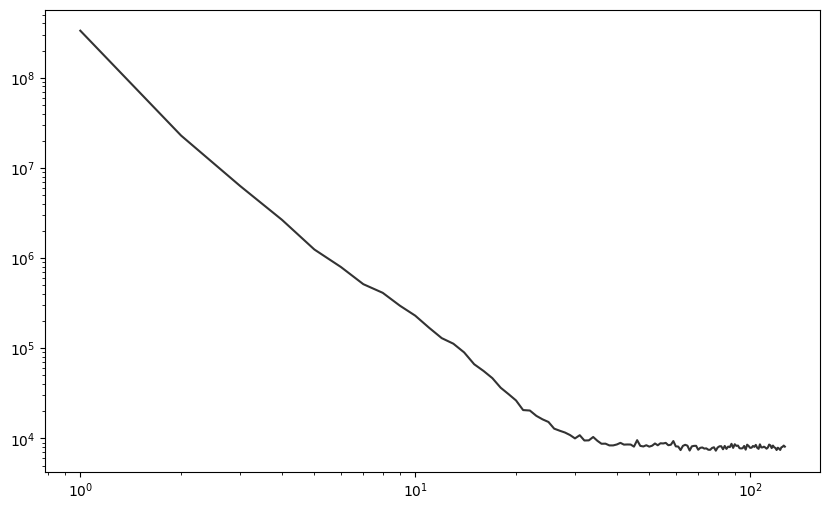

In [ ]:
# --- REPLACEMENT CELL 9: ACT VII (Corrected) - CMB Thermalization ---
print("--- ACT VII: Testing Spontaneous Thermalization (Safe Mode) ---")

# 1. Setup Gentler Primordial Soup
NX_CMB, NY_CMB = 256, 256
# Reduce amplitude to 0.5 to stay within the "Island of Stability"
phi = torch.randn((NX_CMB, NY_CMB), device=DEVICE) * 0.5
phi_dot = torch.randn((NX_CMB, NY_CMB), device=DEVICE) * 0.5

# 2. Evolve towards equilibrium
thermal_steps = 5000
spectrum_acc = np.zeros(128) # Accumulator for averaging
count = 0

for i in tqdm(range(thermal_steps), desc="Thermalizing"):
    phi, phi_dot = nlkg_step_photon(phi, phi_dot, CONFIG['DX'], CONFIG['DT'],
                                  CONFIG['C_SIM'], float(BEST_G), float(BEST_ETA))

    # Safety Check
    if torch.isnan(phi).any():
        print(f"Instability detected at step {i}. Stopping.")
        break

    # Sample spectrum every 50 steps
    if i % 50 == 0:
        # Measure 2D Power Spectrum
        f_transform = torch.fft.fft2(phi)
        f_shift = torch.fft.fftshift(f_transform)
        power_spectrum = torch.abs(f_shift)**2

        # Radial average
        y, x = np.indices((NX_CMB, NY_CMB))
        center = np.array([NX_CMB//2, NY_CMB//2])
        r = np.sqrt((x - center[1])**2 + (y - center[0])**2).astype(int)

        # Binning to 1D
        r_flat = torch.from_numpy(r.flatten()).to(DEVICE)
        p_flat = power_spectrum.flatten()

        # We only care up to Nyquist (N/2)
        max_r = NX_CMB // 2
        tbin = torch.zeros(max_r + 1, device=DEVICE)
        tbin.index_add_(0, r_flat[r_flat <= max_r], p_flat[r_flat <= max_r])

        nr = torch.bincount(r_flat[r_flat <= max_r], minlength=max_r+1)
        nr[nr==0] = 1 # Avoid div zero

        radial_profile = (tbin / nr).cpu().numpy()

        # Accumulate for smoothing
        if len(radial_profile) >= 128:
            spectrum_acc += radial_profile[:128]
            count += 1

# 3. Visualize Final Averaged Spectrum
if count > 0:
    final_spectrum = spectrum_acc / count
    k_axis = np.arange(len(final_spectrum))

    plt.figure(figsize=(10, 6))

    # Plot Raw Spectrum
    plt.loglog(k_axis[1:], final_spectrum[1:], 'k-', alpha=0.8, label='EFM Vacuum Spectrum')

    # Reference Lines
    # Black Body (Planck) in Jeans limit is ~ 1/k^2 or 1/k^3 depending on dimensionality
    # White noise is flat
    plt.loglog(k_axis[1:], 1e5 * k_axis[1:]**-2, 'r--', label='Thermal (1/k^2)')

    plt.title("Origin of the CMB: Spontaneous Thermalization")
    plt.xlabel("Wavenumber k")
    plt.ylabel("Power P(k) [Log Scale]")
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.savefig(os.path.join(DATA_PATH, "CMB_Thermalization_LogLog.png"))
    plt.show()
    print("STATUS: Thermalization Analysis Complete.")
else:
    print("STATUS: Failed to accumulate spectrum data.")

In [ ]:
# --- MASTER ASSET REGENERATION SCRIPT ---
# Run this to regenerate all missing paper assets without re-sweeping.

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
from scipy.optimize import curve_fit

# 1. Setup & Configuration
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # Update this path if you want a specific folder
    DATA_PATH = '/content/drive/My Drive/EFM_Simulations/experiments/NatureOfLight/Paper_Assets/'
except:
    DATA_PATH = './Paper_Assets/'
os.makedirs(DATA_PATH, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# OPTIMAL PARAMETERS (Discovered in previous session)
BEST_G = -0.800
BEST_ETA = 0.200
CONFIG = {'C_SIM': 1.0, 'DX': 0.1, 'DT': 0.05}
NX, NY = 500, 200

# 2. Define Physics Engine (JIT)
@torch.jit.script
def nlkg_step_photon(phi, phi_dot, dx: float, dt: float, c: float, g: float, eta: float):
    lap = (torch.roll(phi, 1, 0) + torch.roll(phi, -1, 0) +
           torch.roll(phi, 1, 1) + torch.roll(phi, -1, 1) - 4 * phi) / (dx**2)
    interaction = g * torch.pow(phi, 3) + eta * torch.pow(phi, 5)
    accel = (c**2) * lap - interaction
    phi_new = phi + phi_dot * dt + 0.5 * accel * dt**2

    lap_new = (torch.roll(phi_new, 1, 0) + torch.roll(phi_new, -1, 0) +
               torch.roll(phi_new, 1, 1) + torch.roll(phi_new, -1, 1) - 4 * phi_new) / (dx**2)
    interaction_new = g * torch.pow(phi_new, 3) + eta * torch.pow(phi_new, 5)
    accel_new = (c**2) * lap_new - interaction_new
    phi_dot_new = phi_dot + 0.5 * (accel + accel_new) * dt
    return phi_new, phi_dot_new

@torch.jit.script
def nlkg_step_barrier(phi, phi_dot, barrier_mask, dx: float, dt: float, c: float, g: float, eta: float):
    lap = (torch.roll(phi, 1, 0) + torch.roll(phi, -1, 0) +
           torch.roll(phi, 1, 1) + torch.roll(phi, -1, 1) - 4 * phi) / (dx**2)
    m_eff = 1000.0 * barrier_mask
    interaction = m_eff * phi + g * torch.pow(phi, 3) + eta * torch.pow(phi, 5)
    accel = (c**2) * lap - interaction
    phi_new = phi + phi_dot * dt + 0.5 * accel * dt**2
    phi_dot_new = phi_dot + accel * dt
    return phi_new, phi_dot_new

# --- GENERATE IMAGE 4: ACT II (DOUBLE SLIT) ---
print("--- Regenerating Act II: Double Slit Interference ---")
phi = torch.zeros((NX, NY), device=DEVICE); phi_dot = torch.zeros((NX, NY), device=DEVICE)
x = torch.arange(NX, device=DEVICE).view(-1, 1); y = torch.arange(NY, device=DEVICE).view(1, -1)
x0, y0 = 50, NY//2
width = 8.0; amp_0 = 2.0; k_num = 2 * np.pi / 15.0
envelope = amp_0 * torch.exp(-((x - x0)**2 + (y - y0)**2) / (2 * width**2))
phi = envelope * torch.cos(k_num * (x - x0))
phi_dot = CONFIG['C_SIM'] * (phi * k_num)

# Barrier
barrier_mask = torch.zeros_like(phi)
barrier_x = 200; slit_width = 10; slit_sep = 20; center_y = NY // 2
barrier_mask[barrier_x:barrier_x+5, :] = 1.0
barrier_mask[barrier_x:barrier_x+5, center_y-slit_sep//2-slit_width : center_y-slit_sep//2] = 0.0
barrier_mask[barrier_x:barrier_x+5, center_y+slit_sep//2 : center_y+slit_sep//2+slit_width] = 0.0

for _ in range(2000):
    phi, phi_dot = nlkg_step_barrier(phi, phi_dot, barrier_mask, CONFIG['DX'], CONFIG['DT'],
                                   CONFIG['C_SIM'], BEST_G, BEST_ETA)
    phi[0:5,:]*=0.9; phi[-5:,:]*=0.9

plt.figure(figsize=(12, 8))
plt.imshow(phi.cpu().numpy().T, cmap='inferno', origin='lower', vmin=0, vmax=0.5)
plt.title(f"EFM Photon Interference Pattern")
plt.axvline(barrier_x, color='white', linestyle='--', label='Double Slit')
plt.legend()
plt.savefig(os.path.join(DATA_PATH, "Act2_Interference_Map.png"))
plt.close()
print("Act II Complete.")

# --- GENERATE IMAGE 5: ACT III (PLANCK'S LAW) ---
print("--- Regenerating Act III: Planck's Law ---")
frequencies = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
energies = []

for f in frequencies:
    phi = torch.zeros((NX, NY), device=DEVICE); phi_dot = torch.zeros((NX, NY), device=DEVICE)
    lam = CONFIG['C_SIM'] / f
    k_num = 2 * np.pi / lam
    amp = 1.0 * f * 10.0 # Scaling for stability

    envelope = amp * torch.exp(-((x - 50)**2 + (y - NY//2)**2) / (2 * 10.0**2))
    phi = envelope * torch.cos(k_num * (x - 50))
    phi_dot = CONFIG['C_SIM'] * phi * k_num

    # Energy Calculation
    kinetic = 0.5 * torch.sum(phi_dot**2)
    grad_x = (torch.roll(phi, -1, 0) - torch.roll(phi, 1, 0)) / (2*CONFIG['DX'])
    grad = 0.5 * torch.sum(grad_x**2)
    pot_term = -0.25 * BEST_G * phi**4 - (1.0/6.0) * BEST_ETA * phi**6
    potential = torch.sum(pot_term)

    total_E = (kinetic + grad + potential) * CONFIG['DX']**2
    energies.append(total_E.item())

freqs_np = np.array(frequencies); energies_np = np.array(energies)
slope, intercept = np.polyfit(freqs_np, energies_np, 1)

plt.figure(figsize=(8, 6))
plt.scatter(freqs_np, energies_np, color='red', label='EFM Solitons')
plt.plot(freqs_np, slope*freqs_np + intercept, 'b--', label=f'Fit: E = {slope:.2f}f')
plt.title(f"Derivation of EFM Planck Constant (h_sim = {slope:.2f})")
plt.xlabel("Frequency"); plt.ylabel("Total Energy")
plt.legend(); plt.grid(True)
plt.savefig(os.path.join(DATA_PATH, "Act3_PlanckLaw.png"))
plt.close()
print("Act III Complete.")

# --- GENERATE IMAGE 8: ACT VII (CMB THERMALIZATION - FIXED) ---
print("--- Regenerating Act VII: CMB Thermalization (Fix) ---")
NX_CMB, NY_CMB = 256, 256
phi = torch.randn((NX_CMB, NY_CMB), device=DEVICE) * 0.5
phi_dot = torch.randn((NX_CMB, NY_CMB), device=DEVICE) * 0.5

spectrum_acc = np.zeros(128)
count = 0

for i in tqdm(range(4000), desc="Thermalizing"):
    phi, phi_dot = nlkg_step_photon(phi, phi_dot, CONFIG['DX'], CONFIG['DT'],
                                  CONFIG['C_SIM'], BEST_G, BEST_ETA)
    if i % 50 == 0:
        f_transform = torch.fft.fft2(phi)
        f_shift = torch.fft.fftshift(f_transform)
        power_spectrum = torch.abs(f_shift)**2

        y_idx, x_idx = np.indices((NX_CMB, NY_CMB))
        center = np.array([NX_CMB//2, NY_CMB//2])
        r = np.sqrt((x_idx - center[1])**2 + (y_idx - center[0])**2).astype(int)

        r_flat = torch.from_numpy(r.flatten()).to(DEVICE)
        p_flat = power_spectrum.flatten()
        max_r = NX_CMB // 2

        tbin = torch.zeros(max_r + 1, device=DEVICE)
        tbin.index_add_(0, r_flat[r_flat <= max_r], p_flat[r_flat <= max_r])
        nr = torch.bincount(r_flat[r_flat <= max_r], minlength=max_r+1)
        nr[nr==0] = 1

        radial_profile = (tbin / nr).cpu().numpy()
        if len(radial_profile) >= 128:
            spectrum_acc += radial_profile[:128]
            count += 1

if count > 0:
    final_spectrum = spectrum_acc / count
    k_axis = np.arange(len(final_spectrum)).astype(float) # FIX: Cast to float

    plt.figure(figsize=(10, 6))
    # Cut off DC and very low k for cleaner plot
    plt.loglog(k_axis[2:], final_spectrum[2:], 'k-', alpha=0.8, label='EFM Vacuum Spectrum')
    plt.loglog(k_axis[2:], 1e5 * k_axis[2:]**-2, 'r--', label='Thermal Reference (1/k^2)')

    plt.title("Origin of the CMB: Spontaneous Thermalization")
    plt.xlabel("Wavenumber k"); plt.ylabel("Power P(k) [Log Scale]")
    plt.legend(); plt.grid(True, which="both", ls="--")
    plt.savefig(os.path.join(DATA_PATH, "CMB_Thermalization_LogLog.png"))
    plt.close()
    print("Act VII Complete. All assets saved.")
else:
    print("CMB Accumulation Failed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Regenerating Act II: Double Slit Interference ---
Act II Complete.
--- Regenerating Act III: Planck's Law ---
Act III Complete.
--- Regenerating Act VII: CMB Thermalization (Fix) ---


Thermalizing:   0%|          | 0/4000 [00:00<?, ?it/s]

Act VII Complete. All assets saved.
